# 05 - Time Series Feature Engineering

**Purpose:** create the modeling table for one-month-ahead community-attention forecasting.

Each row is a business at feature month `t`. The table supports two targets:

- regression: review count in month `t + 1`;
- classification: whether month `t + 1` is an attention pulse.

The cohort keeps businesses with at least **100 reviews** and **36 active months inside the 2015-2021 modeling window**. January 2022 is excluded because it is incomplete.

The features combine time-series history, business metadata, social exposure, and lightweight NLP signals from recent review text.

## Configuration

Define the modeling window, active-business cohort thresholds, attention-pulse rule, and lightweight NLP lexicons. These constants make the target design explicit and easy to audit.


In [1]:
# Configure feature-engineering paths, modeling windows, targets, and NLP settings.
from pathlib import Path
import json
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

INTERIM_DIR = PROJECT_ROOT / "data" / "interim" / "new_orleans"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "new_orleans"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures" / "feature_engineering"
EDA_FIGURES_DIR = OUTPUTS_DIR / "figures" / "eda"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
EDA_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

BUSINESSES_PATH = INTERIM_DIR / "businesses.jsonl"
REVIEWS_PATH = INTERIM_DIR / "reviews.jsonl"
USER_NETWORK_FEATURES_PATH = PROCESSED_DIR / "user_network_features.csv"
FORECASTING_DATASET_PATH = PROCESSED_DIR / "forecasting_dataset.csv"
MODELING_TABLE_WITH_SENTIMENT_PATH = PROCESSED_DIR / "modeling_table_with_sentiment.parquet"
COHORT_BUSINESSES_PATH = PROCESSED_DIR / "forecasting_cohort_businesses.csv"
FEATURE_SUMMARY_PATH = PROCESSED_DIR / "forecasting_feature_summary.json"
TFIDF_TERMS_OUTPUT_PATH = OUTPUTS_DIR / "nlp_tfidf_terms.csv"

MIN_TOTAL_REVIEWS = 100
MIN_ACTIVE_MONTHS = 36
MODELING_START = pd.Period("2015-01", freq="M")
MODELING_END_FEATURE = pd.Period("2021-11", freq="M")
MODELING_END_TARGET = pd.Period("2021-12", freq="M")
EXCLUDED_PARTIAL_MONTH = "2022-01"

PULSE_MIN_TARGET_REVIEWS = 3
PULSE_ABSOLUTE_LIFT = 2
PULSE_RELATIVE_LIFT = 1.5
RECENT_TEXT_WINDOW_MONTHS = 3
TFIDF_MAX_FEATURES = 50
TFIDF_MIN_DF = 20
VADER_POSITIVE_THRESHOLD = 0.05
VADER_NEGATIVE_THRESHOLD = -0.05

pd.set_option("display.max_columns", 120)
plt.rcParams.update({"figure.figsize": (10, 5), "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False})
print(PROJECT_ROOT)

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp


In [2]:
# Define small helper functions for JSON loading, category flags, and text features.
def iter_jsonl(path):
    with path.open("r", encoding="utf-8") as file:
        for line_number, line in enumerate(file, start=1):
            try:
                yield json.loads(line)
            except json.JSONDecodeError as exc:
                raise ValueError(f"Invalid JSON in {path} at line {line_number}") from exc

def has_category(categories, keywords):
    text = str(categories).lower()
    return int(any(keyword in text for keyword in keywords))

POSITIVE_WORDS = {
    "amazing", "awesome", "best", "delicious", "excellent", "favorite", "friendly", "fresh",
    "great", "happy", "love", "loved", "perfect", "recommend", "recommended", "tasty",
    "wonderful",
}
NEGATIVE_WORDS = {
    "awful", "bad", "bland", "cold", "disappointed", "disappointing", "dirty", "horrible",
    "overpriced", "poor", "rude", "slow", "terrible", "unfriendly", "worst",
}
POSITIVE_PATTERN = re.compile(r"\b(" + "|".join(sorted(POSITIVE_WORDS)) + r")\b", flags=re.IGNORECASE)
NEGATIVE_PATTERN = re.compile(r"\b(" + "|".join(sorted(NEGATIVE_WORDS)) + r")\b", flags=re.IGNORECASE)

def count_matches(text, pattern):
    return len(pattern.findall(str(text)))

def safe_tfidf_column_name(term):
    cleaned = re.sub(r"[^0-9a-zA-Z]+", "_", term.lower()).strip("_")
    return f"tfidf_recent_{cleaned[:45]}"

In [3]:
# Load business metadata and review text needed for TS, SNA, and NLP features.
businesses = pd.DataFrame([
    {
        "business_id": r["business_id"],
        "name": r.get("name"),
        "business_stars": r.get("stars"),
        "business_review_count": r.get("review_count"),
        "categories": r.get("categories") or "",
    }
    for r in iter_jsonl(BUSINESSES_PATH)
])

review_rows = []
for r in iter_jsonl(REVIEWS_PATH):
    review_rows.append({
        "review_id": r["review_id"],
        "business_id": r["business_id"],
        "user_id": r["user_id"],
        "stars": float(r["stars"]),
        "date": r["date"],
        "text": r.get("text") or "",
    })
reviews = pd.DataFrame(review_rows)
reviews["date"] = pd.to_datetime(reviews["date"])
reviews["month"] = reviews["date"].dt.to_period("M")
reviews = reviews[reviews["month"].astype(str) != EXCLUDED_PARTIAL_MONTH].copy()

print("businesses", businesses.shape)
print("reviews", reviews.shape, reviews["month"].min(), reviews["month"].max())

businesses (6215, 5)
reviews (633299, 7) 2005-03 2021-12


## Active Modeling Cohort

Select businesses using only the 2015-2021 modeling window. This avoids keeping businesses that qualified historically but were inactive during the period being modeled.


In [4]:
# Select the active business cohort inside the same window used for modeling.
# Build the base business-month signal before adding lagged targets.
# Count reviews per business-month before constructing lag and target features.
monthly_counts = reviews.groupby(["business_id", "month"]).size().rename("monthly_review_count").reset_index()

# Cohort selection is restricted to the same period used for modeling.
# Use only the modeling window for cohort eligibility to avoid historically active but inactive businesses.
modeling_window_counts = monthly_counts[
    (monthly_counts["month"] >= MODELING_START)
    & (monthly_counts["month"] <= MODELING_END_TARGET)
].copy()

business_activity = modeling_window_counts.groupby("business_id").agg(
    total_reviews=("monthly_review_count", "sum"),
    active_months=("month", "nunique"),
).reset_index()

cohort = business_activity[(business_activity["total_reviews"] >= MIN_TOTAL_REVIEWS) & (business_activity["active_months"] >= MIN_ACTIVE_MONTHS)].copy()
cohort = cohort.merge(businesses, on="business_id", how="left")
cohort.to_csv(COHORT_BUSINESSES_PATH, index=False)
cohort_ids = cohort["business_id"].tolist()

print(f"Forecasting cohort businesses: {len(cohort_ids):,}")
cohort[["business_id", "name", "total_reviews", "active_months"]].head()

Forecasting cohort businesses: 876


,business_id,name,total_reviews,active_months
0,-1XSzguS6XLN-V6MVZMg2A,Restaurant Rebirth,528,71
1,-A2OLubXDsMRPNN7LqohPA,Rollin Fatties,154,57
2,-AaxZJ_I4rSFOBJbBz4SlQ,Hansen's Sno-Bliz,360,69
3,-If0ps0QhOLCYVWQWs9RYg,Maple Street Patisserie,100,59
4,-Tskf8WK17rb3ZfeFuRSWA,Palace Café,1281,83


## Monthly Panel and Time-Series Features

Create one row per business-month, then add lagged and rolling review-history features. Target columns always refer to the next month.


In [5]:
# Build the business-month panel and lagged time-series features.
all_months = pd.period_range(reviews["month"].min(), MODELING_END_TARGET, freq="M")
index = pd.MultiIndex.from_product([cohort_ids, all_months], names=["business_id", "feature_month"])
panel = pd.DataFrame(index=index).reset_index()

monthly_star_stats = (
    reviews[reviews["business_id"].isin(cohort_ids)]
    .groupby(["business_id", "month"])
    .agg(monthly_review_count=("review_id", "size"), monthly_star_sum=("stars", "sum"))
    .reset_index()
    .rename(columns={"month": "feature_month"})
)

panel = panel.merge(monthly_star_stats, on=["business_id", "feature_month"], how="left")
panel["monthly_review_count"] = panel["monthly_review_count"].fillna(0).astype(int)
panel["monthly_star_sum"] = panel["monthly_star_sum"].fillna(0.0)
panel = panel.sort_values(["business_id", "feature_month"])

by_business = panel.groupby("business_id", group_keys=False)
panel["prev_month_reviews"] = panel["monthly_review_count"]
panel["rolling_3_avg"] = by_business["monthly_review_count"].rolling(3, min_periods=1).mean().reset_index(level=0, drop=True)
panel["rolling_6_avg"] = by_business["monthly_review_count"].rolling(6, min_periods=1).mean().reset_index(level=0, drop=True)
panel["same_month_previous_year"] = by_business["monthly_review_count"].shift(12).fillna(0)
panel["cumulative_review_count"] = by_business["monthly_review_count"].cumsum()
panel["cumulative_star_sum"] = by_business["monthly_star_sum"].cumsum()
panel["avg_rating_history"] = np.where(panel["cumulative_review_count"] > 0, panel["cumulative_star_sum"] / panel["cumulative_review_count"], 0.0)
# The target is next month, so all feature columns remain anchored at month t.
panel["target_next_month_reviews"] = by_business["monthly_review_count"].shift(-1)
panel["target_month"] = panel["feature_month"] + 1
panel.head()

,business_id,feature_month,monthly_review_count,monthly_star_sum,prev_month_reviews,rolling_3_avg,rolling_6_avg,same_month_previous_year,cumulative_review_count,cumulative_star_sum,avg_rating_history,target_next_month_reviews,target_month
0,-1XSzguS6XLN-V6MVZMg2A,2005-03,0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,2005-04
1,-1XSzguS6XLN-V6MVZMg2A,2005-04,0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,2005-05
2,-1XSzguS6XLN-V6MVZMg2A,2005-05,0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,2005-06
3,-1XSzguS6XLN-V6MVZMg2A,2005-06,0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,2005-07
4,-1XSzguS6XLN-V6MVZMg2A,2005-07,0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,2005-08


In [6]:
# Convert business metadata into compact numeric/context flags.
business_features = businesses.assign(
    is_restaurant=lambda df: df["categories"].apply(lambda x: has_category(x, ["restaurant"])),
    is_food=lambda df: df["categories"].apply(lambda x: has_category(x, ["food", "coffee", "tea", "bakery", "dessert"])),
    is_nightlife=lambda df: df["categories"].apply(lambda x: has_category(x, ["nightlife", "bar", "pub", "cocktail"])),
    is_tourism=lambda df: df["categories"].apply(lambda x: has_category(x, ["hotels & travel", "hotel", "event planning", "arts & entertainment", "local flavor", "tour"])),
)[["business_id", "business_stars", "business_review_count", "is_restaurant", "is_food", "is_nightlife", "is_tourism"]]

panel = panel.merge(business_features, on="business_id", how="left")

In [7]:
# Aggregate recent reviewer-network exposure for each business-month.
user_network_features = pd.read_csv(USER_NETWORK_FEATURES_PATH)
user_network_features["community_id"] = user_network_features["community_id"].fillna(-1).astype(int)
user_first_month = reviews.groupby("user_id")["month"].min().rename("user_first_month").reset_index()

DYNAMIC_ACTIVE_REVIEW_THRESHOLD = 5
HIGH_SOCIAL_SIGNAL_QUANTILE = 0.90

active_network_users = user_network_features[user_network_features["active_reviewer"].eq(1)].copy()
high_weighted_pagerank_cutoff = active_network_users["weighted_pagerank"].quantile(HIGH_SOCIAL_SIGNAL_QUANTILE)
high_weighted_degree_cutoff = active_network_users["friend_weighted_degree"].quantile(HIGH_SOCIAL_SIGNAL_QUANTILE)

reviews["month_number_global"] = reviews["month"].dt.year * 12 + reviews["month"].dt.month
user_month_activity = (
    reviews.groupby(["user_id", "month", "month_number_global"])
    .agg(user_month_review_count=("review_id", "size"))
    .reset_index()
    .sort_values(["user_id", "month_number_global"])
)
user_month_activity["reviewer_reviews_to_date"] = user_month_activity.groupby("user_id")["user_month_review_count"].cumsum()
user_month_activity["reviewer_active_months_to_date"] = user_month_activity.groupby("user_id").cumcount() + 1

reviewers = (
    reviews[reviews["business_id"].isin(cohort_ids)][["business_id", "user_id", "month", "month_number_global"]]
    .drop_duplicates()
    .merge(user_network_features, on="user_id", how="left")
    .merge(user_first_month, on="user_id", how="left")
    .rename(columns={"month_number_global": "review_month_number_global"})
)

network_defaults = {
    "subset_review_count": 0,
    "active_reviewer": 0,
    "friend_degree": 0,
    "friend_weighted_degree": 0.0,
    "pagerank": 0.0,
    "weighted_pagerank": 0.0,
    "avg_friend_shared_businesses": 0.0,
    "avg_friend_category_overlap": 0.0,
    "component_id": -1,
    "component_size": 0,
    "community_id": -1,
}
for column, value in network_defaults.items():
    if column not in reviewers.columns:
        reviewers[column] = value
    reviewers[column] = reviewers[column].fillna(value)

# Expand each reviewer observation into the trailing 3-month feature window.
recent_frames = []
for offset in [0, 1, 2]:
    temp = reviewers.copy()
    temp["feature_month"] = temp["month"] + offset
    recent_frames.append(temp)
recent_reviewers = pd.concat(recent_frames, ignore_index=True)
recent_reviewers = recent_reviewers[(recent_reviewers["feature_month"] >= all_months.min()) & (recent_reviewers["feature_month"] <= all_months.max())].copy()
recent_reviewers["feature_month_number_global"] = recent_reviewers["feature_month"].dt.year * 12 + recent_reviewers["feature_month"].dt.month

recent_reviewers = pd.merge_asof(
    recent_reviewers.sort_values(["feature_month_number_global", "user_id"]),
    user_month_activity[[
        "user_id",
        "month_number_global",
        "reviewer_reviews_to_date",
        "reviewer_active_months_to_date",
    ]].sort_values(["month_number_global", "user_id"]),
    left_on="feature_month_number_global",
    right_on="month_number_global",
    by="user_id",
    direction="backward",
).drop(columns=["month_number_global"])

recent_reviewers["reviewer_reviews_to_date"] = recent_reviewers["reviewer_reviews_to_date"].fillna(0)
recent_reviewers["reviewer_active_months_to_date"] = recent_reviewers["reviewer_active_months_to_date"].fillna(0)
recent_reviewers["reviewer_recency_months"] = recent_reviewers["feature_month_number_global"] - recent_reviewers["review_month_number_global"]
recent_reviewers["is_current_month_reviewer"] = recent_reviewers["reviewer_recency_months"].eq(0).astype(int)
recent_reviewers["is_repeat_reviewer"] = (recent_reviewers["user_first_month"] < recent_reviewers["feature_month"]).astype(int)
recent_reviewers["is_active_to_date_reviewer"] = (recent_reviewers["reviewer_reviews_to_date"] >= DYNAMIC_ACTIVE_REVIEW_THRESHOLD).astype(int)
recent_reviewers["is_connected_reviewer"] = (recent_reviewers["friend_degree"] > 0).astype(int)
recent_reviewers["is_weighted_connected_reviewer"] = (recent_reviewers["friend_weighted_degree"] > 0).astype(int)
recent_reviewers["is_largest_component_reviewer"] = recent_reviewers["component_id"].eq(0).astype(int)
recent_reviewers["is_high_weighted_pagerank_reviewer"] = (recent_reviewers["weighted_pagerank"] >= high_weighted_pagerank_cutoff).astype(int)
recent_reviewers["is_high_weighted_degree_reviewer"] = (recent_reviewers["friend_weighted_degree"] >= high_weighted_degree_cutoff).astype(int)

network_agg = recent_reviewers.groupby(["business_id", "feature_month"]).agg(
    recent_reviewer_count=("user_id", "nunique"),
    avg_reviewer_degree=("friend_degree", "mean"),
    avg_reviewer_weighted_degree=("friend_weighted_degree", "mean"),
    max_reviewer_pagerank=("pagerank", "max"),
    max_reviewer_weighted_pagerank=("weighted_pagerank", "max"),
    avg_reviewer_weighted_pagerank=("weighted_pagerank", "mean"),
    sum_reviewer_weighted_pagerank=("weighted_pagerank", "sum"),
    sum_reviewer_weighted_degree=("friend_weighted_degree", "sum"),
    avg_reviewer_friend_shared_businesses=("avg_friend_shared_businesses", "mean"),
    avg_reviewer_friend_category_overlap=("avg_friend_category_overlap", "mean"),
    fraction_connected_reviewers=("is_connected_reviewer", "mean"),
    fraction_weighted_connected_reviewers=("is_weighted_connected_reviewer", "mean"),
    fraction_repeat_reviewers=("is_repeat_reviewer", "mean"),
    fraction_active_to_date_reviewers=("is_active_to_date_reviewer", "mean"),
    avg_reviewer_reviews_to_date=("reviewer_reviews_to_date", "mean"),
    max_reviewer_reviews_to_date=("reviewer_reviews_to_date", "max"),
    avg_reviewer_active_months_to_date=("reviewer_active_months_to_date", "mean"),
    fraction_largest_component_reviewers=("is_largest_component_reviewer", "mean"),
    fraction_high_weighted_pagerank_reviewers=("is_high_weighted_pagerank_reviewer", "mean"),
    fraction_high_weighted_degree_reviewers=("is_high_weighted_degree_reviewer", "mean"),
    avg_reviewer_recency_months=("reviewer_recency_months", "mean"),
    fraction_current_month_reviewers=("is_current_month_reviewer", "mean"),
    reviewer_community_diversity=("community_id", lambda values: values[values >= 0].nunique()),
).reset_index()

panel = panel.merge(network_agg, on=["business_id", "feature_month"], how="left")
static_social_features = [
    "recent_reviewer_count",
    "avg_reviewer_degree",
    "avg_reviewer_weighted_degree",
    "max_reviewer_pagerank",
    "max_reviewer_weighted_pagerank",
    "avg_reviewer_weighted_pagerank",
    "sum_reviewer_weighted_pagerank",
    "sum_reviewer_weighted_degree",
    "avg_reviewer_friend_shared_businesses",
    "avg_reviewer_friend_category_overlap",
    "fraction_connected_reviewers",
    "fraction_weighted_connected_reviewers",
    "fraction_repeat_reviewers",
    "reviewer_community_diversity",
]
dynamic_social_exposure_features = [
    "fraction_active_to_date_reviewers",
    "avg_reviewer_reviews_to_date",
    "max_reviewer_reviews_to_date",
    "avg_reviewer_active_months_to_date",
    "fraction_largest_component_reviewers",
    "fraction_high_weighted_pagerank_reviewers",
    "fraction_high_weighted_degree_reviewers",
    "avg_reviewer_recency_months",
    "fraction_current_month_reviewers",
]
network_feature_columns = static_social_features + dynamic_social_exposure_features
for col in network_feature_columns:
    panel[col] = panel[col].fillna(0)

panel.head()

,business_id,feature_month,monthly_review_count,monthly_star_sum,prev_month_reviews,rolling_3_avg,rolling_6_avg,same_month_previous_year,cumulative_review_count,cumulative_star_sum,avg_rating_history,target_next_month_reviews,target_month,business_stars,business_review_count,is_restaurant,is_food,is_nightlife,is_tourism,recent_reviewer_count,avg_reviewer_degree,avg_reviewer_weighted_degree,max_reviewer_pagerank,max_reviewer_weighted_pagerank,avg_reviewer_weighted_pagerank,sum_reviewer_weighted_pagerank,sum_reviewer_weighted_degree,avg_reviewer_friend_shared_businesses,avg_reviewer_friend_category_overlap,fraction_connected_reviewers,fraction_weighted_connected_reviewers,fraction_repeat_reviewers,fraction_active_to_date_reviewers,avg_reviewer_reviews_to_date,max_reviewer_reviews_to_date,avg_reviewer_active_months_to_date,fraction_largest_component_reviewers,fraction_high_weighted_pagerank_reviewers,fraction_high_weighted_degree_reviewers,avg_reviewer_recency_months,fraction_current_month_reviewers,reviewer_community_diversity
0,-1XSzguS6XLN-V6MVZMg2A,2005-03,0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,2005-04,4.5,521,1,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-1XSzguS6XLN-V6MVZMg2A,2005-04,0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,2005-05,4.5,521,1,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-1XSzguS6XLN-V6MVZMg2A,2005-05,0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,2005-06,4.5,521,1,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-1XSzguS6XLN-V6MVZMg2A,2005-06,0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,2005-07,4.5,521,1,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-1XSzguS6XLN-V6MVZMg2A,2005-07,0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,2005-08,4.5,521,1,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Community-Level Review Time Series

This section moves from business-month activity to reviewer-community activity. It directly ties the social-network communities back to the forecasting theme by asking whether large reviewer groups have their own aggregate review rhythms before we model individual businesses.

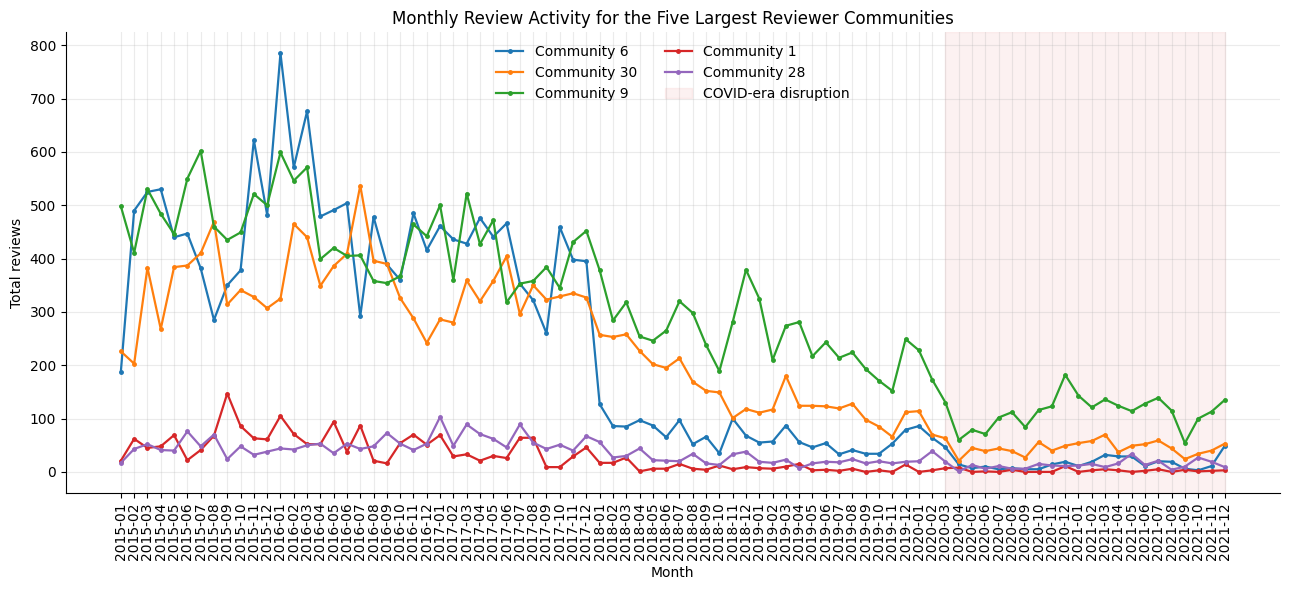

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\data\processed\new_orleans\community_month_series.csv
C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\feature_engineering\community_review_trends.png


,community_id,year_month,total_reviews,unique_businesses_reviewed,mean_stars,community_size,is_top5_community
0,6,2015-01,188,159,3.984043,1708,True
1,6,2015-02,490,304,4.077551,1708,True
2,6,2015-03,525,308,3.988571,1708,True
3,6,2015-04,530,311,3.892453,1708,True
4,6,2015-05,440,280,3.922727,1708,True


In [8]:
# Assign reviewer communities and build community-month review activity series.
IN_NOTEBOOK = "get_ipython" in globals()
if not IN_NOTEBOOK:
    plt.switch_backend("Agg")

COMMUNITY_MONTH_SERIES_PATH = PROCESSED_DIR / "community_month_series.csv"
COMMUNITY_TRENDS_PATH = FIGURES_DIR / "community_review_trends.png"

if "reviews_df" not in globals():
    reviews_df = reviews.copy()
reviews_df = reviews_df.copy()
reviews_df["date"] = pd.to_datetime(reviews_df["date"])
reviews_df["year_month"] = reviews_df["date"].dt.to_period("M")
reviews_df = reviews_df[
    (reviews_df["year_month"] >= pd.Period("2015-01", freq="M"))
    & (reviews_df["year_month"] <= pd.Period("2021-12", freq="M"))
].copy()

if "community_labels" in globals():
    community_label_frame = (
        pd.Series(community_labels, name="community_id")
        .rename_axis("user_id")
        .reset_index()
    )
else:
    if "user_network_features" not in globals():
        user_network_features = pd.read_csv(USER_NETWORK_FEATURES_PATH)
    community_label_frame = user_network_features[["user_id", "community_id"]].copy()

community_label_frame["community_id"] = community_label_frame["community_id"].fillna(-1).astype(int)
community_label_frame = community_label_frame.drop_duplicates("user_id")

reviews_with_communities = reviews_df.merge(community_label_frame, on="user_id", how="left")
reviews_with_communities["community_id"] = reviews_with_communities["community_id"].fillna(-1).astype(int)
community_reviews = reviews_with_communities[reviews_with_communities["community_id"] >= 0].copy()

community_sizes = (
    community_label_frame[community_label_frame["community_id"] >= 0]
    .groupby("community_id")["user_id"]
    .nunique()
    .rename("community_size")
    .reset_index()
    .sort_values("community_size", ascending=False)
)
top5_community_ids = community_sizes.head(5)["community_id"].tolist()
community_size_lookup = community_sizes.set_index("community_id")["community_size"].to_dict()

community_month_series = (
    community_reviews
    .groupby(["community_id", "year_month"])
    .agg(
        total_reviews=("business_id", "size"),
        unique_businesses_reviewed=("business_id", "nunique"),
        mean_stars=("stars", "mean"),
    )
    .reset_index()
    .merge(community_sizes, on="community_id", how="left")
)
community_month_series["is_top5_community"] = community_month_series["community_id"].isin(top5_community_ids)

all_community_months = pd.period_range("2015-01", "2021-12", freq="M")
top5_index = pd.MultiIndex.from_product(
    [top5_community_ids, all_community_months],
    names=["community_id", "year_month"],
)
top5_community_month_series = (
    pd.DataFrame(index=top5_index)
    .reset_index()
    .merge(community_month_series, on=["community_id", "year_month"], how="left", suffixes=("", "_observed"))
)
top5_community_month_series["total_reviews"] = top5_community_month_series["total_reviews"].fillna(0).astype(int)
top5_community_month_series["unique_businesses_reviewed"] = top5_community_month_series["unique_businesses_reviewed"].fillna(0).astype(int)
top5_community_month_series["community_size"] = top5_community_month_series["community_id"].map(community_size_lookup).astype(int)
top5_community_month_series["is_top5_community"] = True

community_month_series_output = pd.concat(
    [
        community_month_series[~community_month_series["community_id"].isin(top5_community_ids)],
        top5_community_month_series,
    ],
    ignore_index=True,
    sort=False,
)
community_month_series_output["year_month"] = community_month_series_output["year_month"].astype(str)
community_month_series_output = community_month_series_output.sort_values(["community_id", "year_month"])
community_month_series_output.to_csv(COMMUNITY_MONTH_SERIES_PATH, index=False)

fig, ax = plt.subplots(figsize=(13, 6))
for community_id in top5_community_ids:
    plot_df = top5_community_month_series[top5_community_month_series["community_id"].eq(community_id)].sort_values("year_month")
    ax.plot(
        plot_df["year_month"].astype(str),
        plot_df["total_reviews"],
        marker="o",
        markersize=2.5,
        linewidth=1.6,
        label=f"Community {community_id}",
    )
ax.axvspan("2020-03", "2021-12", color="#E45756", alpha=0.08, label="COVID-era disruption")
ax.set_title("Monthly Review Activity for the Five Largest Reviewer Communities")
ax.set_xlabel("Month")
ax.set_ylabel("Total reviews")
ax.tick_params(axis="x", rotation=90)
ax.legend(frameon=False, ncol=2)
fig.tight_layout()
fig.savefig(COMMUNITY_TRENDS_PATH, dpi=160)
if IN_NOTEBOOK:
    plt.show()
plt.close(fig)

print(COMMUNITY_MONTH_SERIES_PATH)
print(COMMUNITY_TRENDS_PATH)
top5_community_month_series.head()


### Community Trend Notes

The five largest reviewer communities are selected by labeled user count from the train-only SNA graph, not by review volume. Tthe top community IDs are `6`, `30`, `9`, `1`, and `28`; community `9` has the largest aggregate review stream, while community `6` has the largest labeled user count but much lower post-training review volume.

The main visual lesson is: reviewer communities have readable aggregate rhythms, but the labels now come only from 2015-2017 social structure. Validation, test, and later COVID-era activity are used to evaluate and interpret those fixed communities, not to define them.


## Recent Text and Social Exposure

Aggregate only information available up to feature month `t`: recent review text, recent reviewers, and reviewer-network exposure. This protects the workflow from future leakage.

The NLP block now includes two levels of signal:

- compact lexicon and review-length summaries;
- TF-IDF topic indicators from recent reviews, limited to 50 terms for readability and model control.

In [ ]:
# Aggregate recent review-language features, including capped TF-IDF topic indicators.
nlp_reviews = reviews[reviews["business_id"].isin(cohort_ids)][["review_id", "business_id", "month", "stars", "text"]].copy()
nlp_reviews["text"] = nlp_reviews["text"].fillna("").astype(str)
nlp_reviews["review_char_count"] = nlp_reviews["text"].str.len()
nlp_reviews["review_word_count"] = nlp_reviews["text"].str.split().str.len().fillna(0)
nlp_reviews["positive_word_hits"] = nlp_reviews["text"].apply(lambda text: count_matches(text, POSITIVE_PATTERN))
nlp_reviews["negative_word_hits"] = nlp_reviews["text"].apply(lambda text: count_matches(text, NEGATIVE_PATTERN))
nlp_reviews["has_positive_language"] = nlp_reviews["positive_word_hits"].gt(0).astype(int)
nlp_reviews["has_negative_language"] = nlp_reviews["negative_word_hits"].gt(0).astype(int)

recent_text_frames = []
for offset in range(RECENT_TEXT_WINDOW_MONTHS):
    temp = nlp_reviews.copy()
    temp["feature_month"] = temp["month"] + offset
    recent_text_frames.append(temp)

recent_text_reviews = pd.concat(recent_text_frames, ignore_index=True)
recent_text_reviews = recent_text_reviews[
    (recent_text_reviews["feature_month"] >= all_months.min())
    & (recent_text_reviews["feature_month"] <= all_months.max())
].copy()

# TF-IDF features are topic indicators. The vocabulary is capped so
# it adds interpretability without turning this into a heavy NLP pipeline.
# Fit a small, interpretable vocabulary of recent review terms.
tfidf_vectorizer = TfidfVectorizer(
    max_features=TFIDF_MAX_FEATURES,
    min_df=TFIDF_MIN_DF,
    max_df=0.80,
    stop_words="english",
    ngram_range=(1, 2),
)
tfidf_matrix = tfidf_vectorizer.fit_transform(nlp_reviews["text"])
tfidf_terms = list(tfidf_vectorizer.get_feature_names_out())
tfidf_feature_columns = []
used_tfidf_columns = set()
for term in tfidf_terms:
    base_name = safe_tfidf_column_name(term)
    column_name = base_name
    suffix = 2
    while column_name in used_tfidf_columns:
        column_name = f"{base_name}_{suffix}"
        suffix += 1
    used_tfidf_columns.add(column_name)
    tfidf_feature_columns.append(column_name)

tfidf_df = pd.DataFrame.sparse.from_spmatrix(tfidf_matrix, columns=tfidf_feature_columns)
tfidf_df = tfidf_df.sparse.to_dense()
tfidf_df.insert(0, "review_id", nlp_reviews["review_id"].values)
tfidf_terms_df = pd.DataFrame({"term": tfidf_terms, "feature": tfidf_feature_columns})
tfidf_terms_df.to_csv(TFIDF_TERMS_OUTPUT_PATH, index=False)

recent_text_reviews = recent_text_reviews.merge(tfidf_df, on="review_id", how="left")

nlp_agg_spec = {
    "recent_text_review_count": ("review_id", "size"),
    "avg_recent_review_char_count": ("review_char_count", "mean"),
    "avg_recent_review_word_count": ("review_word_count", "mean"),
    "share_recent_positive_language": ("has_positive_language", "mean"),
    "share_recent_negative_language": ("has_negative_language", "mean"),
    "avg_recent_positive_word_hits": ("positive_word_hits", "mean"),
    "avg_recent_negative_word_hits": ("negative_word_hits", "mean"),
    "recent_text_avg_stars": ("stars", "mean"),
}
for column in tfidf_feature_columns:
    nlp_agg_spec[column] = (column, "mean")

nlp_agg = recent_text_reviews.groupby(["business_id", "feature_month"]).agg(**nlp_agg_spec).reset_index()

nlp_feature_columns = [
    "recent_text_review_count",
    "avg_recent_review_char_count",
    "avg_recent_review_word_count",
    "share_recent_positive_language",
    "share_recent_negative_language",
    "avg_recent_positive_word_hits",
    "avg_recent_negative_word_hits",
    "recent_text_avg_stars",
] + tfidf_feature_columns

panel = panel.merge(nlp_agg, on=["business_id", "feature_month"], how="left")
for col in nlp_feature_columns:
    panel[col] = panel[col].fillna(0)

panel[["business_id", "feature_month"] + nlp_feature_columns].head()

,business_id,feature_month,recent_text_review_count,avg_recent_review_char_count,avg_recent_review_word_count,share_recent_positive_language,share_recent_negative_language,avg_recent_positive_word_hits,avg_recent_negative_word_hits,recent_text_avg_stars,tfidf_recent_amazing,tfidf_recent_bar,tfidf_recent_best,tfidf_recent_came,tfidf_recent_chicken,tfidf_recent_come,tfidf_recent_day,tfidf_recent_definitely,tfidf_recent_delicious,tfidf_recent_did,tfidf_recent_didn,tfidf_recent_don,tfidf_recent_drinks,tfidf_recent_eat,tfidf_recent_experience,tfidf_recent_food,tfidf_recent_fried,tfidf_recent_friendly,tfidf_recent_good,tfidf_recent_got,tfidf_recent_great,tfidf_recent_just,tfidf_recent_like,tfidf_recent_little,tfidf_recent_love,tfidf_recent_meal,tfidf_recent_menu,tfidf_recent_new,tfidf_recent_new_orleans,tfidf_recent_nice,tfidf_recent_night,tfidf_recent_nola,tfidf_recent_order,tfidf_recent_ordered,tfidf_recent_orleans,tfidf_recent_oysters,tfidf_recent_people,tfidf_recent_place,tfidf_recent_really,tfidf_recent_recommend,tfidf_recent_restaurant,tfidf_recent_service,tfidf_recent_shrimp,tfidf_recent_staff,tfidf_recent_table,tfidf_recent_time,tfidf_recent_try,tfidf_recent_ve,tfidf_recent_wait,tfidf_recent_went
0,-1XSzguS6XLN-V6MVZMg2A,2005-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-1XSzguS6XLN-V6MVZMg2A,2005-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-1XSzguS6XLN-V6MVZMg2A,2005-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-1XSzguS6XLN-V6MVZMg2A,2005-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-1XSzguS6XLN-V6MVZMg2A,2005-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## VADER Sentiment Features


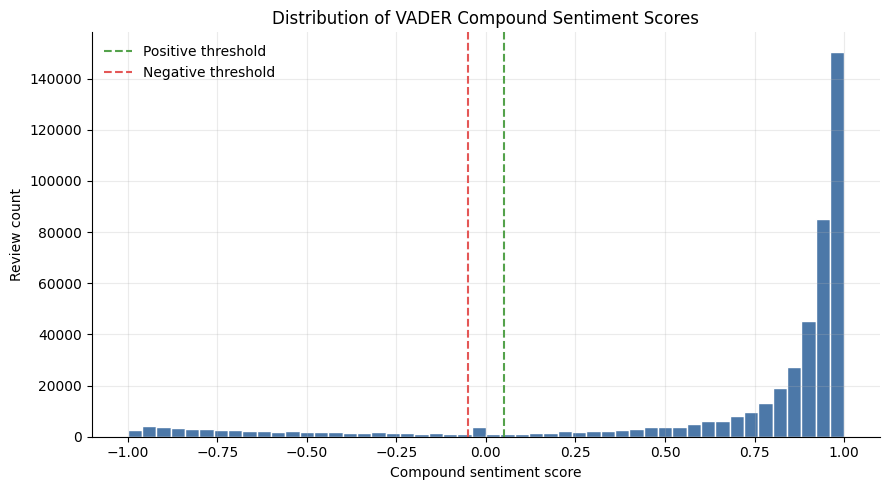

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\eda\sentiment_distribution.png


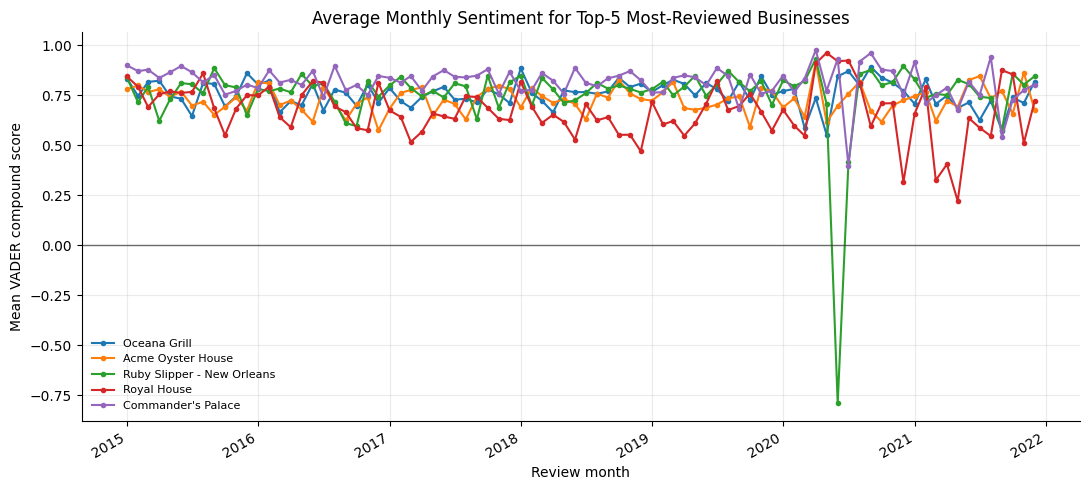

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\eda\sentiment_trend_top5.png


(              business_id feature_month  sentiment_compound_mean  \
 0  -1XSzguS6XLN-V6MVZMg2A       2005-03                      0.0   
 1  -1XSzguS6XLN-V6MVZMg2A       2005-04                      0.0   
 2  -1XSzguS6XLN-V6MVZMg2A       2005-05                      0.0   
 3  -1XSzguS6XLN-V6MVZMg2A       2005-06                      0.0   
 4  -1XSzguS6XLN-V6MVZMg2A       2005-07                      0.0   
 
    sentiment_positive_pct  sentiment_negative_pct  
 0                     0.0                     0.0  
 1                     0.0                     0.0  
 2                     0.0                     0.0  
 3                     0.0                     0.0  
 4                     0.0                     0.0  ,
 {'review_count': 462862,
  'mean_compound': 0.6925056965142957,
  'median_compound': 0.9227,
  'positive_review_pct': 87.72009799897161,
  'negative_review_pct': 11.184975219395845,
  'neutral_review_pct': 1.0949267816325385})

In [10]:
# Score each review with VADER and merge monthly business sentiment into the panel.
reviews_df = reviews[["business_id", "user_id", "stars", "text", "date"]].copy()
reviews_df["text"] = reviews_df["text"].fillna("").astype(str)
reviews_df["year_month"] = reviews_df["date"].dt.to_period("M")
reviews_df = reviews_df[(reviews_df["year_month"] >= MODELING_START) & (reviews_df["year_month"] <= MODELING_END_TARGET)].copy()

sentiment_analyzer = SentimentIntensityAnalyzer()
reviews_df["compound"] = reviews_df["text"].apply(lambda text: sentiment_analyzer.polarity_scores(text)["compound"])
reviews_df["is_positive_sentiment"] = reviews_df["compound"].gt(VADER_POSITIVE_THRESHOLD)
reviews_df["is_negative_sentiment"] = reviews_df["compound"].lt(VADER_NEGATIVE_THRESHOLD)

monthly_sentiment = (
    reviews_df
    .groupby(["business_id", "year_month"])
    .agg(
        sentiment_compound_mean=("compound", "mean"),
        sentiment_positive_pct=("is_positive_sentiment", lambda values: values.mean() * 100),
        sentiment_negative_pct=("is_negative_sentiment", lambda values: values.mean() * 100),
    )
    .reset_index()
    .rename(columns={"year_month": "feature_month"})
)

sentiment_feature_columns = [
    "sentiment_compound_mean",
    "sentiment_positive_pct",
    "sentiment_negative_pct",
]

panel = panel.merge(monthly_sentiment, on=["business_id", "feature_month"], how="left")
for column in sentiment_feature_columns:
    panel[column] = panel[column].fillna(0.0)

sentiment_distribution_summary = {
    "review_count": int(len(reviews_df)),
    "mean_compound": float(reviews_df["compound"].mean()),
    "median_compound": float(reviews_df["compound"].median()),
    "positive_review_pct": float(reviews_df["is_positive_sentiment"].mean() * 100),
    "negative_review_pct": float(reviews_df["is_negative_sentiment"].mean() * 100),
    "neutral_review_pct": float((~reviews_df["is_positive_sentiment"] & ~reviews_df["is_negative_sentiment"]).mean() * 100),
}

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(reviews_df["compound"], bins=50, color="#4C78A8", edgecolor="white")
ax.axvline(VADER_POSITIVE_THRESHOLD, color="#54A24B", linestyle="--", linewidth=1.5, label="Positive threshold")
ax.axvline(VADER_NEGATIVE_THRESHOLD, color="#E45756", linestyle="--", linewidth=1.5, label="Negative threshold")
ax.set_title("Distribution of VADER Compound Sentiment Scores")
ax.set_xlabel("Compound sentiment score")
ax.set_ylabel("Review count")
ax.legend(frameon=False)
fig.tight_layout()
sentiment_distribution_path = EDA_FIGURES_DIR / "sentiment_distribution.png"
fig.savefig(sentiment_distribution_path, dpi=160, bbox_inches="tight")
plt.show()
print(sentiment_distribution_path)

top5_business_ids = reviews_df["business_id"].value_counts().head(5).index.tolist()
business_name_lookup = businesses.set_index("business_id")["name"].to_dict()

def sentiment_plot_label(business_id):
    label = business_name_lookup.get(business_id) or business_id
    return label if len(label) <= 38 else f"{label[:35]}..."

fig, ax = plt.subplots(figsize=(11, 5))
for business_id in top5_business_ids:
    trend = monthly_sentiment[monthly_sentiment["business_id"].eq(business_id)].sort_values("feature_month").copy()
    trend["month_start"] = trend["feature_month"].dt.to_timestamp()
    ax.plot(trend["month_start"], trend["sentiment_compound_mean"], marker="o", markersize=3, linewidth=1.5, label=sentiment_plot_label(business_id))

ax.axhline(0, color="#333333", linewidth=1, alpha=0.7)
ax.set_title("Average Monthly Sentiment for Top-5 Most-Reviewed Businesses")
ax.set_xlabel("Review month")
ax.set_ylabel("Mean VADER compound score")
ax.legend(frameon=False, fontsize=8)
fig.autofmt_xdate()
fig.tight_layout()
sentiment_trend_path = EDA_FIGURES_DIR / "sentiment_trend_top5.png"
fig.savefig(sentiment_trend_path, dpi=160, bbox_inches="tight")
plt.show()
print(sentiment_trend_path)

panel[["business_id", "feature_month"] + sentiment_feature_columns].head(), sentiment_distribution_summary


### Sentiment Distribution Interpretation

The scored 2015-2021 New Orleans review text is strongly positive-skewed: VADER classifies about 87.7% of reviews as positive and 11.2% as negative, with a mean compound score near 0.693 and a much higher median of 0.923. That pattern suggests the local Yelp community often reviews to endorse memorable restaurants, tours, nightlife, and hospitality experiences; for forecasting, the useful signal is likely not just the high positive baseline, but month-to-month movement in positivity and spikes in negative sentiment around specific businesses.


## Final Dataset and Validation

Apply the attention-pulse definition, remove pre-first-review rows and save the modeling table.

In [11]:
# Finalize targets, remove inactive leading rows, validate leakage checks, and save the table.
modeling = panel[(panel["feature_month"] >= MODELING_START) & (panel["feature_month"] <= MODELING_END_FEATURE)].copy()
# Drop inactive leading rows so notebook previews start with meaningful business activity.
first_active_feature_month = (
    panel[panel["monthly_review_count"] > 0]
    .groupby("business_id")["feature_month"]
    .min()
    .rename("first_active_feature_month")
)
modeling = modeling.merge(first_active_feature_month, on="business_id", how="left")
pre_first_review_rows = int((modeling["feature_month"] < modeling["first_active_feature_month"]).sum())
# Remove rows before the business first appears in the modeling window.
modeling = modeling[modeling["feature_month"] >= modeling["first_active_feature_month"]].copy()

modeling["feature_month_str"] = modeling["feature_month"].astype(str)
modeling["target_month_str"] = modeling["target_month"].astype(str)
modeling["calendar_month"] = modeling["feature_month"].dt.month
modeling["month_sin"] = np.sin(2 * np.pi * modeling["calendar_month"] / 12)
modeling["month_cos"] = np.cos(2 * np.pi * modeling["calendar_month"] / 12)
modeling["feature_month_number"] = (modeling["feature_month"].dt.year - 2015) * 12 + modeling["feature_month"].dt.month

modeling["pulse_baseline_reviews"] = modeling["rolling_6_avg"]
modeling["pulse_relative_lift"] = modeling["target_next_month_reviews"] / np.maximum(modeling["pulse_baseline_reviews"], 1)
modeling["attention_pulse"] = (
    (modeling["target_next_month_reviews"] >= PULSE_MIN_TARGET_REVIEWS)
    & (modeling["target_next_month_reviews"] >= modeling["pulse_baseline_reviews"] + PULSE_ABSOLUTE_LIFT)
    & (modeling["target_next_month_reviews"] >= PULSE_RELATIVE_LIFT * np.maximum(modeling["pulse_baseline_reviews"], 1))
).astype(int)

modeling["first_active_feature_month_str"] = modeling["first_active_feature_month"].astype(str)
modeling = modeling.drop(columns=["feature_month", "target_month", "first_active_feature_month"])

assert modeling["target_next_month_reviews"].notna().all()
assert not (modeling["target_month_str"] >= "2022-01").any()
assert (cohort["total_reviews"] >= MIN_TOTAL_REVIEWS).all()
assert (cohort["active_months"] >= MIN_ACTIVE_MONTHS).all()
assert (modeling["feature_month_str"] < modeling["target_month_str"]).all()
assert (modeling["feature_month_str"] >= modeling["first_active_feature_month_str"]).all()
assert all(column in modeling.columns for column in dynamic_social_exposure_features)
assert all(column in modeling.columns for column in nlp_feature_columns)
assert all(column in modeling.columns for column in sentiment_feature_columns)
assert modeling["attention_pulse"].isin([0, 1]).all()

modeling.to_csv(FORECASTING_DATASET_PATH, index=False)
modeling.to_parquet(MODELING_TABLE_WITH_SENTIMENT_PATH, index=False)
summary = {
    "min_total_reviews": MIN_TOTAL_REVIEWS,
    "min_active_months": MIN_ACTIVE_MONTHS,
    "business_count": len(cohort_ids),
    "row_count": len(modeling),
    "feature_month_min": modeling["feature_month_str"].min(),
    "feature_month_max": modeling["feature_month_str"].max(),
    "target_month_min": modeling["target_month_str"].min(),
    "target_month_max": modeling["target_month_str"].max(),
    "excluded_partial_month": EXCLUDED_PARTIAL_MONTH,
    "excluded_pre_first_review_rows": pre_first_review_rows,
    "cohort_activity_window": {
        "start": str(MODELING_START),
        "end": str(MODELING_END_TARGET),
        "min_total_reviews": MIN_TOTAL_REVIEWS,
        "min_active_months": MIN_ACTIVE_MONTHS,
    },
    "attention_pulse_definition": {
        "min_target_reviews": PULSE_MIN_TARGET_REVIEWS,
        "absolute_lift_vs_rolling_6": PULSE_ABSOLUTE_LIFT,
        "relative_lift_vs_rolling_6_or_one": PULSE_RELATIVE_LIFT,
    },
    "attention_pulse_rate": float(modeling["attention_pulse"].mean()),
    "recent_text_window_months": RECENT_TEXT_WINDOW_MONTHS,
    "nlp_features": nlp_feature_columns,
    "sentiment_features": sentiment_feature_columns,
    "tfidf_feature_count": len(tfidf_feature_columns),
    "tfidf_terms_output": str(TFIDF_TERMS_OUTPUT_PATH),
    "dynamic_active_review_threshold": DYNAMIC_ACTIVE_REVIEW_THRESHOLD,
    "high_social_signal_quantile": HIGH_SOCIAL_SIGNAL_QUANTILE,
    "static_social_features": static_social_features,
    "dynamic_social_exposure_features": dynamic_social_exposure_features,
    "output": str(FORECASTING_DATASET_PATH),
    "sentiment_output": str(MODELING_TABLE_WITH_SENTIMENT_PATH),
}
with FEATURE_SUMMARY_PATH.open("w", encoding="utf-8") as file:
    json.dump(summary, file, indent=2)
    file.write("\n")
summary

{'min_total_reviews': 100,
 'min_active_months': 36,
 'business_count': 876,
 'row_count': 68249,
 'feature_month_min': '2015-01',
 'feature_month_max': '2021-11',
 'target_month_min': '2015-02',
 'target_month_max': '2021-12',
 'excluded_partial_month': '2022-01',
 'excluded_pre_first_review_rows': 4459,
 'cohort_activity_window': {'start': '2015-01',
  'end': '2021-12',
  'min_total_reviews': 100,
  'min_active_months': 36},
 'attention_pulse_definition': {'min_target_reviews': 3,
  'absolute_lift_vs_rolling_6': 2,
  'relative_lift_vs_rolling_6_or_one': 1.5},
 'attention_pulse_rate': 0.1377895646822664,
 'recent_text_window_months': 3,
 'nlp_features': ['recent_text_review_count',
  'avg_recent_review_char_count',
  'avg_recent_review_word_count',
  'share_recent_positive_language',
  'share_recent_negative_language',
  'avg_recent_positive_word_hits',
  'avg_recent_negative_word_hits',
  'recent_text_avg_stars',
  'tfidf_recent_amazing',
  'tfidf_recent_bar',
  'tfidf_recent_best',


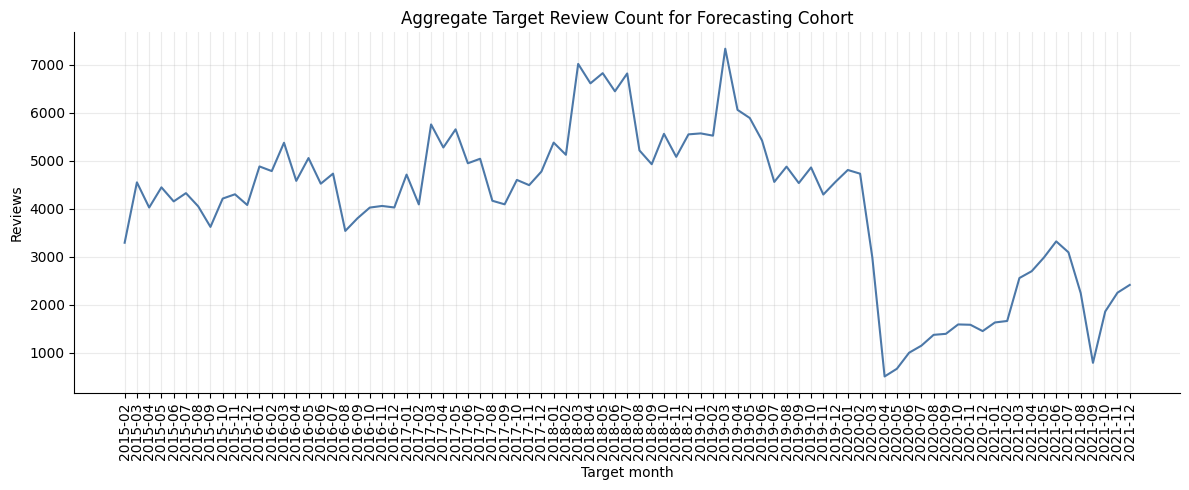

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\feature_engineering\cohort_monthly_target_reviews.png


In [12]:
# Save a figure of aggregate target-month review volume for the cohort.
monthly_target = modeling.groupby("target_month_str")["target_next_month_reviews"].sum()
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_target.index, monthly_target.values, color="#4C78A8")
ax.set_title("Aggregate Target Review Count for Forecasting Cohort")
ax.set_xlabel("Target month")
ax.set_ylabel("Reviews")
ax.tick_params(axis="x", rotation=90)
fig.tight_layout()
path = FIGURES_DIR / "cohort_monthly_target_reviews.png"
fig.savefig(path, dpi=160)
plt.show()
plt.close(fig)
print(path)

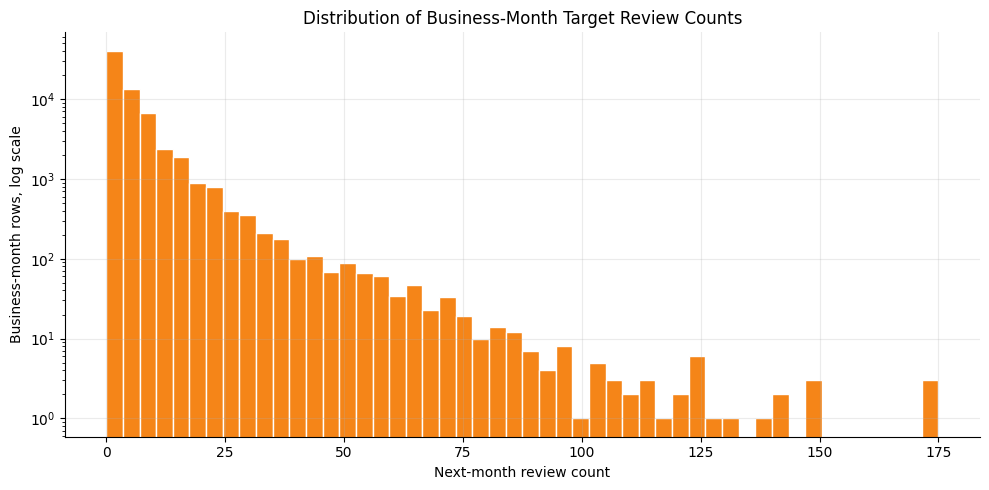

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\feature_engineering\target_review_count_distribution.png


In [13]:
# Save the target distribution figure with log-scaled counts.
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(modeling["target_next_month_reviews"], bins=50, color="#F58518", edgecolor="white")
ax.set_yscale("log")
ax.set_title("Distribution of Business-Month Target Review Counts")
ax.set_xlabel("Next-month review count")
ax.set_ylabel("Business-month rows, log scale")
fig.tight_layout()
path = FIGURES_DIR / "target_review_count_distribution.png"
fig.savefig(path, dpi=160)
plt.show()
plt.close(fig)
print(path)

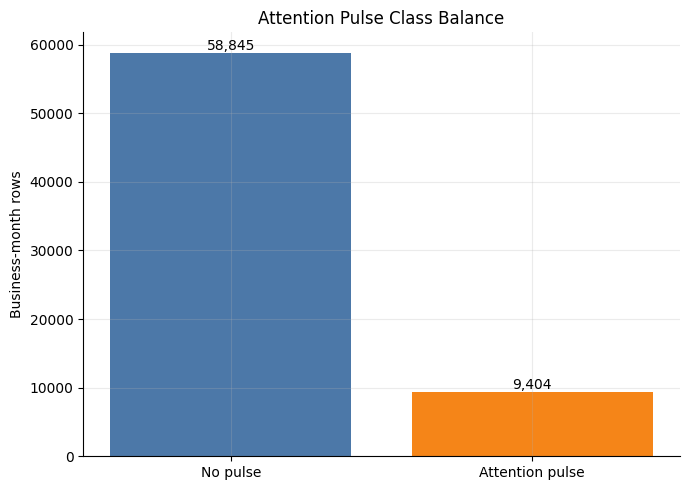

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\feature_engineering\attention_pulse_class_balance.png


In [14]:
# Save the attention-pulse class-balance figure.
pulse_counts = modeling["attention_pulse"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(["No pulse", "Attention pulse"], [pulse_counts.get(0, 0), pulse_counts.get(1, 0)], color=["#4C78A8", "#F58518"])
ax.set_title("Attention Pulse Class Balance")
ax.set_ylabel("Business-month rows")
for index, value in enumerate([pulse_counts.get(0, 0), pulse_counts.get(1, 0)]):
    ax.text(index, value, f"{value:,}", ha="center", va="bottom")
fig.tight_layout()
path = FIGURES_DIR / "attention_pulse_class_balance.png"
fig.savefig(path, dpi=160)
plt.show()
plt.close(fig)
print(path)

## Feature-Engineering Limitations

- The attention-pulse rule is intentionally interpretable, but it is still a design choice rather than an observed ground truth label.
- Community labels come from the active reviewer graph; reviews by unlabeled users are assigned `community_id = -1` and excluded from community-month aggregation.
- Community-month series smooth out business-level noise, but they do not identify which specific businesses will receive attention.
- NLP features are lightweight lexicon, VADER sentiment, text-length, and capped TF-IDF signals; they improve interpretability but do not replace deeper semantic modeling.
- TF-IDF values use only recent reviews for each business-month, but the vocabulary itself is selected globally as a simple feature set mainly for interpretability.
- VADER is rule-based sentiment analysis, so sarcasm, local slang, and mixed food/service experiences can still be misread.

## Feature-Engineering Takeaways

- The cohort is selected using activity inside the actual **2015-2021 modeling window**, not the full historical Yelp period.
- Rows before each business's first observed modeling-window review are excluded, avoiding artificial all-zero pre-visibility periods.
- Attention pulses flag unusual next-month review increases relative to each business's rolling 6-month baseline.
- Community-month series show that large reviewer communities have aggregate rhythms and visible 2020-2021 disruption, but business-month rows remain the forecasting target.
- NLP features use only reviews from the feature month and previous two months.
- VADER sentiment features summarize same-month review tone as mean compound score plus positive and negative review percentages.
- SNA features describe recent reviewers as of the feature month.
- The saved figures document aggregate review activity, community trends, target skew, attention-pulse class balance, and sentiment patterns.